RQs:
- What is the distribution of contract type between occupations/sectors?
- What is the distribution of salary between occupations/sectors?
    - Avg annual increase by sector?
    - Stretch: hourly pay / annual pay / annualised pay?
- What proportion of ads in each occupation/sector mention learning and development/career progression/CPD?
- What proportion of ads in each occupation/sector mention flexible hours/flexible shifts?

Stretch: unsupervised approach: topic modelling of JQ sentences in early years sector vs a comparison sector

Limitations:
- The sample only covers the years 2021-2023 inclusive

In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

from dap_job_quality import PROJECT_DIR
from dap_job_quality.getters.keywords import get_keywords

In [2]:
afs_raw_sample = pd.read_parquet('s3://open-jobs-lake/job_quality/early_years/evaluation_sample/job_ads_sample_size_16392.parquet')
processed_ads = pd.read_parquet('s3://open-jobs-lake/job_quality/outputs/afs/job_ads_prod_True_n_16392_2024-08-12.parquet')
salary_info = pd.read_parquet('s3://open-jobs-lake/job_quality/early_years/evaluation_sample/job_ads_sample_size_16392_metadata_production_True.parquet')
lookup = get_keywords()

2024-08-15 11:40:47,613 - aiobotocore.credentials - INFO - Found credentials in shared credentials file: ~/.aws/credentials


In [3]:
print(f"The complete sample includes {len(afs_raw_sample)} job adverts")

The complete sample includes 16392 job adverts


In [4]:
print(f"The sectors to which EYP roles are compared are: {afs_raw_sample['sector'].unique()}")

The sectors to which EYP roles are compared are: ['Early Years Practitioner' 'Primary School Teacher' 'Retail Assistant'
 'Secondary School Teacher' 'Special Needs Teacher' 'Supply Teacher'
 'Teaching Assistant' 'Waiter']


In [5]:
afs_raw_sample.groupby(['sector', 'itl_1_name']).agg('size').unstack(fill_value=0).to_csv('sector_itl1.csv')

In [6]:
afs_raw_sample['sector'].value_counts()

sector
Early Years Practitioner    2049
Primary School Teacher      2049
Retail Assistant            2049
Secondary School Teacher    2049
Special Needs Teacher       2049
Supply Teacher              2049
Teaching Assistant          2049
Waiter                      2049
Name: count, dtype: int64

In [7]:
afs_raw_sample.groupby(['itl_1_name']).agg('size').to_csv('itl1.csv')

In [8]:
processed_ads = processed_ads[['id', 'sentences_split', 'target_phrase']].drop_duplicates()
processed_ads

,id,sentences_split,target_phrase
0,43993867,Hours can range between 8 and 40 hours per w...,X hours p w
1,43993867,Hours can range between 8 and 40 hours per w...,XX hours per week
2,43993867,Hours can range between 8 and 40 hours per w...,flexible working hours
3,42104494,Weekly pay through our Pay as You Earn scheme.,pay
4,43241293,4 days at Easter,XX days holiday
...,...,...,...
73476,47201393,£350- £375 per week.,X days per week
73477,46715601,£375-£425 per week Borough Southwark Timeplan...,employee assistance programme
73478,46715601,£375-£425 per week Borough Southwark Timeplan...,learning & development
73479,46366565,£120-£189.54 per day,X days per week


In [9]:
lookup

,dimension,subcategory,target_phrase,Notes
0,barriers to access,CARING,caring responsibilities,NaN
1,barriers to access,CARING,childcare vouchers,NaN
2,barriers to access,CARING,discount on childcare,NaN
3,barriers to access,CARING,parental leave,NaN
4,barriers to access,CARING,maternity,NaN
...,...,...,...,...
110,employment terms,LOC,field-based,NaN
111,work life balance,FLEX_LOC,hybrid,NaN
112,employment terms,LOC,office-based,NaN
113,work life balance,FLEX_LOC,remote,NaN


In [10]:
processed_ads = pd.merge(processed_ads, lookup[['target_phrase', 'subcategory','dimension']], on='target_phrase', how='left')
processed_ads

,id,sentences_split,target_phrase,subcategory,dimension
0,43993867,Hours can range between 8 and 40 hours per w...,X hours p w,HOURS,employment terms
1,43993867,Hours can range between 8 and 40 hours per w...,XX hours per week,HOURS,employment terms
2,43993867,Hours can range between 8 and 40 hours per w...,flexible working hours,FLEX_HOURS,work life balance
3,42104494,Weekly pay through our Pay as You Earn scheme.,pay,COMP,pay and benefits
4,43241293,4 days at Easter,XX days holiday,LEAVE,pay and benefits
...,...,...,...,...,...
73476,47201393,£350- £375 per week.,X days per week,HOURS,employment terms
73477,46715601,£375-£425 per week Borough Southwark Timeplan...,employee assistance programme,PERKS,pay and benefits
73478,46715601,£375-£425 per week Borough Southwark Timeplan...,learning & development,L&D,job design and nature of work
73479,46366565,£120-£189.54 per day,X days per week,HOURS,employment terms


In [11]:
dimensions_wide = processed_ads[['id', 'subcategory']].drop_duplicates()
dimensions_wide['value'] = 1
dimensions_wide = dimensions_wide.pivot(index='id', columns='subcategory').fillna(0)
dimensions_wide.columns = dimensions_wide.columns.get_level_values(1)
dimensions_wide = dimensions_wide.reset_index()

In [12]:
dimensions_wide

subcategory,id,AUTONOMY,CAREER,CARING,COMP,CONTRACT,DISABILITY,FLEX_HOURS,FLEX_LOC,HEALTH,...,LEAVE,LOC,MISC,M_HEALTH,PERKS,REWARD,SENSE OF PURPOSE,SHIFT,SOCIAL,SPONSORSHIP
0,41656216,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,41656534,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,41661813,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,41665100,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,41667954,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10165,51565376,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10166,51566228,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10167,51567609,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10168,51569444,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [13]:
afs_sample = pd.merge(afs_raw_sample, dimensions_wide, on='id', how='left')

In [14]:
columns_to_replace = dimensions_wide.columns[1:] # the first column is the id

In [15]:
# These columns have NaN where there are *no* mentions of JQ dimensions in these job adverts
afs_sample[columns_to_replace] = afs_sample[columns_to_replace].fillna(0)

In [16]:
def plot_proportion(df=afs_sample, dim='FLEX_HOURS', save_path=None):
    # Step 1: Filter the DataFrame for rows where FLEX_HOURS is 1.0
    filtered_df = df[df[dim] == 1.0]

    # Step 2: Group the filtered DataFrame by 'sector' and count the number of occurrences
    count_df = filtered_df.groupby('sector')['id'].count()

    # Step 3: Group the original DataFrame by 'sector' and count the total number of occurrences
    total_count = df.groupby('sector')['id'].count()

    # Step 4: Calculate the proportion of FLEX_HOURS==1.0 for each sector
    proportion_df = (count_df / total_count) * 100
    proportion_df = proportion_df.sort_values(ascending=False)

    # Step 5: Prepare the figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))

    # Step 6: Plot the results using a horizontal bar chart, scaling the width by the number of 'id' in that category
    bars = ax.barh(proportion_df.index, proportion_df.values, color='skyblue', edgecolor='black')

    # # Step 7: Annotate the bars with the proportions
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.0f}%', 
                va='center', ha='left', color='black', fontsize=10)

    # Step 8: Scale the width of the bars by the number of 'id' in that category
    # ax.bar_label(bars, labels=[f'{int(total_count.loc[sector])}' for sector in proportion_flex_hours.index], padding=3)

    # Step 9: Set labels and title
    ax.set_xlabel('Proportion (%)')
    ax.set_ylabel('Sector')
    ax.set_title(f'Proportion of job ads mentioning {dim} by Sector')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

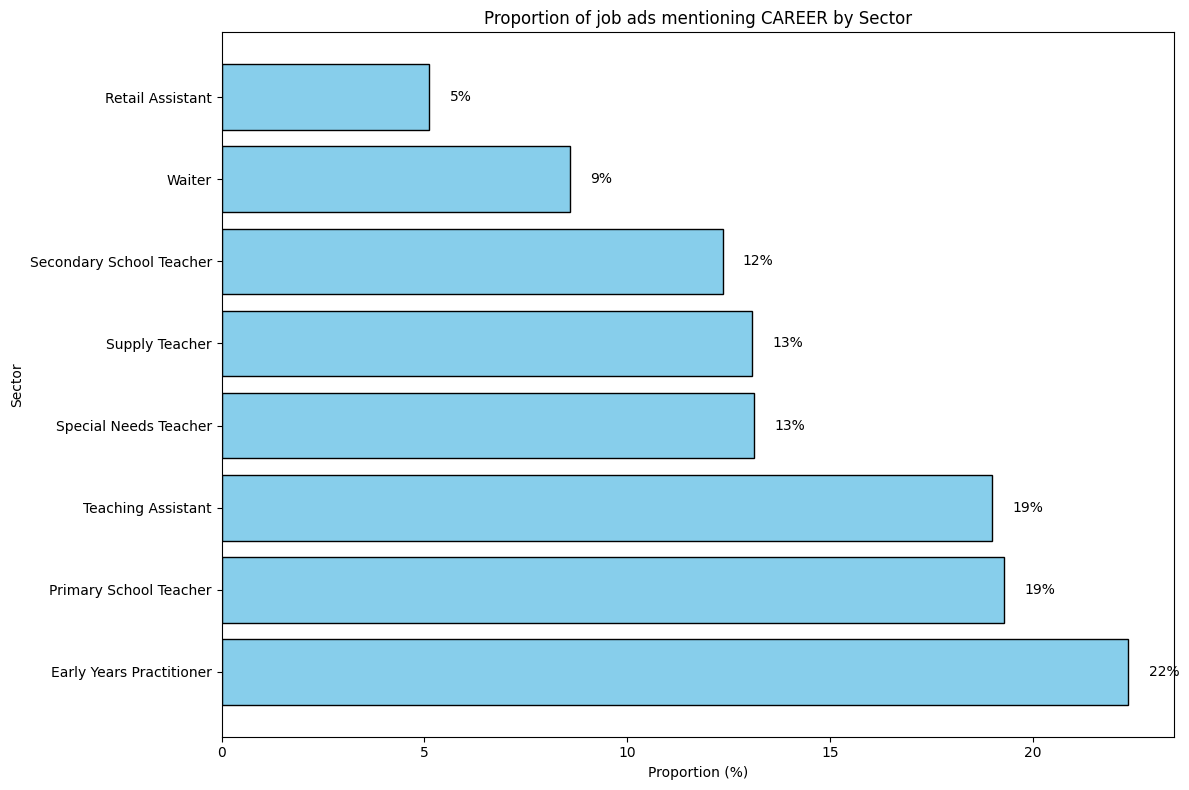

In [17]:
plot_proportion(afs_sample, 'CAREER')

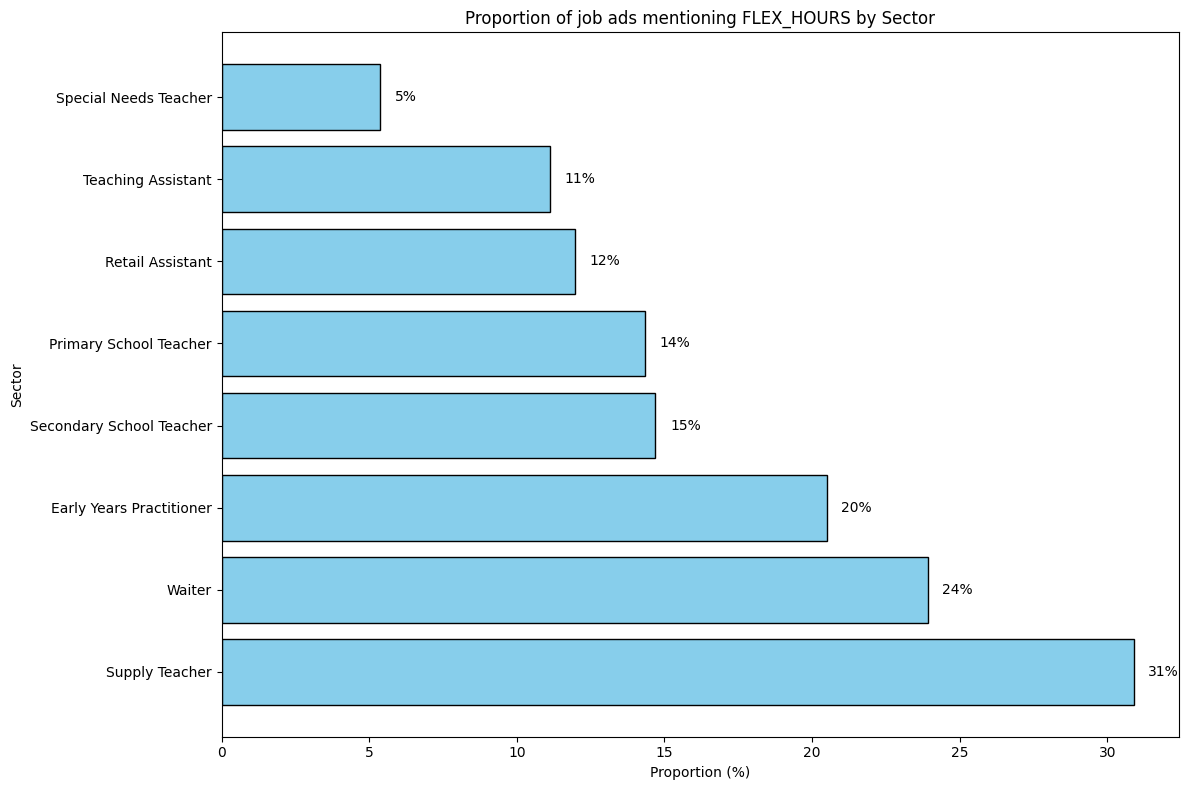

In [18]:
plot_proportion(afs_sample, 'FLEX_HOURS', save_path=PROJECT_DIR / 'outputs/figures/afs/prop_flex_hours_by_sector.png')

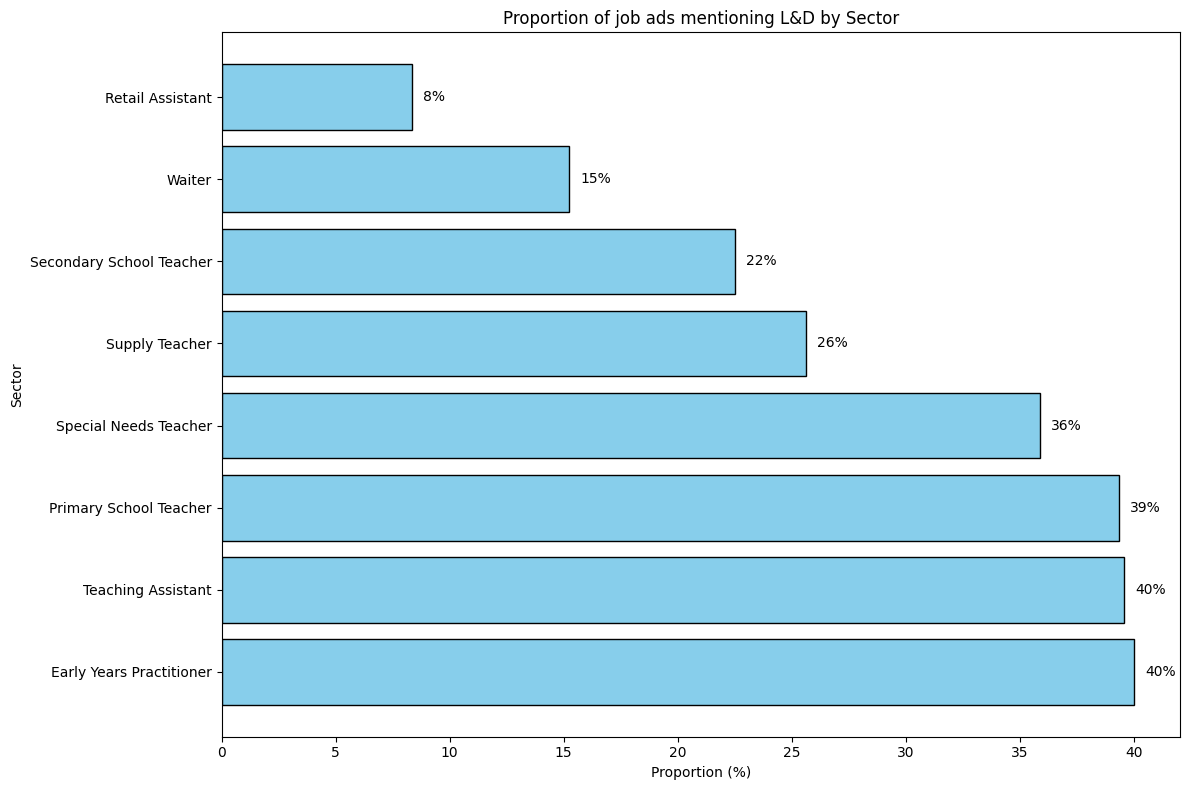

In [19]:
plot_proportion(afs_sample, 'L&D', save_path=PROJECT_DIR / 'outputs/figures/afs/prop_l&d_by_sector.png')

In [20]:
salary_info.head()

,id,created,job_title_raw,job_location_raw,company_raw,contract_type_raw,type,sector,parent_sector,knowledge_domain,...,raw_min_salary,raw_max_salary,raw_salary_unit,raw_salary_currency,salary_competitive,salary_negotiable,s3_location,raw_salary_float,raw_min_salary_float,raw_max_salary_float
0,42049959,17/02/2021,Store Assistant Fixed Term,"Carmarthen, Dyfed",Aldi,Temporary,Direct employer,Store Staff,Retail,Sales,...,None,None,None,None,True,False,most_recent_jobs/production/reed/reed-42049959...,NaN,NaN,NaN
1,42051641,18/02/2021,Store Assistant - Days,"Easton Royal, Wiltshire",ASDA,Temporary,Direct employer,Other Retail,Retail,Sales,...,None,None,None,None,True,False,most_recent_jobs/production/reed/reed-42051641...,NaN,NaN,NaN
2,42052447,18/02/2021,Secondary Teachers with QTS,"Blackpool, Lancashire",Vida Education,Temporary,Recruitment consultancy,Key Stage 3 &amp; 4,Education,Education,...,110.0000,189.0000,DAY,GBP,False,False,most_recent_jobs/production/reed/reed-42052447...,110.0,110.0,189.0
3,42052483,18/02/2021,Secondary Teachers with QTS,"Preston, Lancashire",Vida Education,Temporary,Recruitment consultancy,Key Stage 3 &amp; 4,Education,Education,...,110.0000,189.0000,DAY,GBP,False,False,most_recent_jobs/production/reed/reed-42052483...,110.0,110.0,189.0
4,42053105,18/02/2021,Teaching Assistant,"Bexley, Kent",REED,Temporary,Recruitment consultancy,Key Stage 2,Education,Education,...,None,None,None,None,False,True,most_recent_jobs/production/reed/reed-42053105...,NaN,NaN,NaN


In [21]:
salary_info['raw_salary_unit'].value_counts(dropna=False)

raw_salary_unit
DAY     7216
None    3625
HOUR    2880
YEAR    2671
Name: count, dtype: int64

In [22]:
missing_salary_df = salary_info[salary_info['raw_salary_unit'].isna()]

In [23]:
def extract_salary_info(text):
    # Regular expression to match the salary pattern
    salary_pattern = re.compile(
        r"£\s*(\d+(?:,\d{3})*(?:\.\d{2})?)\s*(?:-|to)?\s*£?\s*(\d+(?:,\d{3})*(?:\.\d{2})?)?\s*(per\s*(hour|day|annum|year))?",
        re.IGNORECASE
    )

    matches = salary_pattern.findall(text)
    salary_info = []

    for match in matches:
        min_salary = float(match[0].replace(',', ''))
        max_salary = float(match[1].replace(',', '')) if match[1] else min_salary
        rate = match[3].lower() if match[3] else "year"  # Default to per year if not specified

        salary_info.append({
            'min_salary': min_salary,
            'max_salary': max_salary,
            'rate': rate
        })

    return salary_info

# Example usage
text = """
Pay £120.00 - £140.00 per day
What we Offer: £13.00 - £15.00 per hour inclusive of service charge
£21,650 base
£24,950 OTE
Salary: £21,500 (FTE equivalent)
£110 - £120 per day
£9.60 per hour
£21,000-22,000 per annum
£14.00 - £16.00 per hour
£65 to £95 per day
"""

test_salaries = extract_salary_info(text)
for sal in test_salaries:
    print(sal)


{'min_salary': 120.0, 'max_salary': 140.0, 'rate': 'day'}
{'min_salary': 13.0, 'max_salary': 15.0, 'rate': 'hour'}
{'min_salary': 21650.0, 'max_salary': 21650.0, 'rate': 'year'}
{'min_salary': 24950.0, 'max_salary': 24950.0, 'rate': 'year'}
{'min_salary': 21500.0, 'max_salary': 21500.0, 'rate': 'year'}
{'min_salary': 110.0, 'max_salary': 120.0, 'rate': 'day'}
{'min_salary': 9.6, 'max_salary': 9.6, 'rate': 'hour'}
{'min_salary': 21000.0, 'max_salary': 22000.0, 'rate': 'annum'}
{'min_salary': 14.0, 'max_salary': 16.0, 'rate': 'hour'}
{'min_salary': 65.0, 'max_salary': 95.0, 'rate': 'day'}


In [24]:
extract_salary_info("From £9.50 per hour")

[{'min_salary': 9.5, 'max_salary': 9.5, 'rate': 'hour'}]

In [25]:
salary_descs = missing_salary_df['description'].tolist()
salaries = [extract_salary_info(desc) for desc in salary_descs]

In [26]:
# There are some weird values eg £3000 per year. This is because there are lots of 'refer a friend' bonuses that mess up the extraction a bit!
salaries

[[],
 [],
 [{'min_salary': 100.0, 'max_salary': 100.0, 'rate': 'year'}],
 [],
 [{'min_salary': 120.0, 'max_salary': 140.0, 'rate': 'day'}],
 [],
 [],
 [{'min_salary': 13.0, 'max_salary': 15.0, 'rate': 'hour'}],
 [{'min_salary': 3000.0, 'max_salary': 3000.0, 'rate': 'year'}],
 [{'min_salary': 250.0, 'max_salary': 250.0, 'rate': 'year'}],
 [{'min_salary': 300.0, 'max_salary': 300.0, 'rate': 'year'}],
 [],
 [{'min_salary': 3000.0, 'max_salary': 3000.0, 'rate': 'year'}],
 [],
 [],
 [],
 [{'min_salary': 13.0, 'max_salary': 15.0, 'rate': 'hour'}],
 [],
 [],
 [{'min_salary': 3000.0, 'max_salary': 3000.0, 'rate': 'year'}],
 [{'min_salary': 3000.0, 'max_salary': 3000.0, 'rate': 'year'}],
 [{'min_salary': 250.0, 'max_salary': 250.0, 'rate': 'year'},
  {'min_salary': 250.0, 'max_salary': 250.0, 'rate': 'year'}],
 [{'min_salary': 3000.0, 'max_salary': 3000.0, 'rate': 'year'}],
 [{'min_salary': 24950.0, 'max_salary': 24950.0, 'rate': 'year'},
  {'min_salary': 21650.0, 'max_salary': 21650.0, 'rate':

In [27]:
# An example of a ad that includes a £3000 refer-a-friend bonus
missing_salary_df.iloc[8]['description']

'[ Do you love meeting new people on a daily basis? Are you looking for a role where you can let your personality shine? We’re looking for a Commis Waiter to come and join our team. We look for people who are comfortable in bringing themselves to work, me mean the real you – not work you, as we want you to let your personality shine! We’re a passionate bunch, who are  on a mission to make it special for our guests, whatever the occasion! Sound like something you could get on board with? The good stuff.  We pay all our teams fortnightly because who doesn’t love a payday?Every shift you work, we’ve got you covered with meals from our employee menu (thanks Chef)!Treat yourself, family and friends to 50% discount off our food at any CôteWe love meeting new people who share our passion of making it special, which means you can earn up to £3,000 for referring people to join CôteDiscounts up for grabs with over 200 retailers and brands via PerkboxWe take well-being seriously, so you’ll have a

In [28]:
data = []
for sublist in salaries:
    if sublist:
        data.extend(sublist)
    else:
        data.append({'min_salary': None, 'max_salary': None, 'rate': None})

In [29]:
extracted_salaries_df = pd.DataFrame(data)
extracted_salaries_df['salary'] = extracted_salaries_df['min_salary'].fillna(0)
extracted_salaries_df.head()

,min_salary,max_salary,rate,salary
0,NaN,NaN,None,0.0
1,NaN,NaN,None,0.0
2,100.0,100.0,year,100.0
3,NaN,NaN,None,0.0
4,120.0,140.0,day,120.0


In [30]:
missing_salary_df['raw_salary_unit'] = extracted_salaries_df['rate']
missing_salary_df['raw_salary_float'] = extracted_salaries_df['salary']
missing_salary_df['raw_min_salary_float'] = extracted_salaries_df['min_salary']
missing_salary_df['raw_max_salary_float'] = extracted_salaries_df['max_salary']

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_94953/1241272972.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_salary_df['raw_salary_unit'] = extracted_salaries_df['rate']
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_94953/1241272972.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_salary_df['raw_salary_float'] = extracted_salaries_df['salary']
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_94953/1241272972.py:3: SettingWithCopyWarning: 
A value 

In [31]:
enhanced_salary_data = pd.concat([missing_salary_df, salary_info[~salary_info['raw_salary_unit'].isna()]])

In [32]:
enhanced_salary_data['raw_salary_unit'] = enhanced_salary_data['raw_salary_unit'].str.lower()
enhanced_salary_data['raw_salary_unit'] = enhanced_salary_data['raw_salary_unit'].replace('', np.nan)
enhanced_salary_data['raw_salary_unit'] = enhanced_salary_data['raw_salary_unit'].replace('annum', 'year')

In [33]:
enhanced_salary_data['raw_salary_unit'].value_counts(dropna=False)

raw_salary_unit
day     7262
year    3069
hour    2934
NaN     2614
None     513
Name: count, dtype: int64

In [34]:
# Check how many ads have the salary expressed per annum
enhanced_salary_data['is_annualised'] = enhanced_salary_data['raw_salary_unit'] == 'year'
enhanced_salary_data['is_annualised'].value_counts(dropna=False)

is_annualised
False    13323
True      3069
Name: count, dtype: int64

In [35]:
afs_sample_enhanced = pd.merge(afs_raw_sample, enhanced_salary_data[['id', 'raw_salary_unit', 'raw_salary_float', 'raw_min_salary_float', 'raw_max_salary_float','is_annualised']], on='id', how='left')

In [36]:
# Check that the merge was 1-1, and did not introduce duplicates
len(afs_sample_enhanced) - len(afs_raw_sample)

0

In [37]:
# Filter the data to only records that have some kind of salary info
afs_sample_enhanced_w_salaries = afs_sample_enhanced[afs_sample_enhanced['raw_salary_unit'].notna()]

In [38]:
# proportion of ads offering an annualised salary
grouped = afs_sample_enhanced_w_salaries.groupby(['sector', 'is_annualised']).size().unstack(fill_value=0)
grouped['proportion_annualised'] = grouped[True] / grouped.sum(axis=1)
grouped

is_annualised,False,True,proportion_annualised
sector,,,
Early Years Practitioner,961,734,0.433038
Primary School Teacher,1230,449,0.267421
Retail Assistant,1039,427,0.291269
Secondary School Teacher,1431,303,0.174740
Special Needs Teacher,1214,524,0.301496
Supply Teacher,1648,104,0.059361
Teaching Assistant,1558,208,0.117780
Waiter,1115,320,0.222997


In [39]:
grouped.to_csv('prop_annualised_salary.csv')

In [40]:
afs_sample_enhanced_w_salaries[['raw_salary_unit', 'raw_salary_float', 'raw_min_salary_float',
       'raw_max_salary_float', 'is_annualised']]

,raw_salary_unit,raw_salary_float,raw_min_salary_float,raw_max_salary_float,is_annualised
0,hour,NaN,9.0,10.0,False
1,day,65.00,65.0,75.0,False
2,year,33000.00,NaN,NaN,True
3,year,NaN,21652.0,22214.0,True
4,year,20000.00,20000.0,29000.0,True
...,...,...,...,...,...
16387,hour,10.00,NaN,NaN,False
16388,hour,12.00,NaN,NaN,False
16389,year,NaN,21898.0,23000.0,True
16390,hour,12.22,NaN,NaN,False


In [41]:
afs_sample_enhanced_w_salaries['raw_salary_float'] = afs_sample_enhanced_w_salaries['raw_salary_float'].fillna(afs_sample_enhanced_w_salaries['raw_min_salary_float'])

def calculate_hourly_wage(row, hours_per_day = 7.5, hours_per_year = 37.5*52):
    """Infer hourly pay.
    
    If the pay is given per hour, accept this amount.

    Args:
        row (_type_): _description_
        hours_per_day (float, optional): _description_. Defaults to 7.5.
        hours_per_year (_type_, optional): _description_. Defaults to 37.5*52.

    Returns:
        _type_: _description_
    """
    if row['raw_salary_unit'] == 'hour':
        return row['raw_salary_float']
    elif row['raw_salary_unit'] == 'day':
        return row['raw_salary_float'] / hours_per_day
    elif row['raw_salary_unit'] == 'year':
        return row['raw_salary_float'] / hours_per_year
    else:
        return np.nan

afs_sample_enhanced_w_salaries['hourly_wage'] = afs_sample_enhanced_w_salaries.apply(calculate_hourly_wage, axis=1)

/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_94953/881595558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  afs_sample_enhanced_w_salaries['raw_salary_float'] = afs_sample_enhanced_w_salaries['raw_salary_float'].fillna(afs_sample_enhanced_w_salaries['raw_min_salary_float'])
/var/folders/x3/w5p1j0m5745bvc10jk_w36900000gn/T/ipykernel_94953/881595558.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  afs_sample_enhanced_w_salaries['hourly_wage'] = afs_sample_enhanced_w_salaries.apply(calcu

In the next chunks we check the distribution of hourly wage and exclude outlying data.

In [42]:
afs_sample_enhanced_w_salaries['hourly_wage'].describe()

count    13265.000000
mean        13.402227
std          6.282629
min          0.000000
25%         10.100000
50%         13.186667
75%         16.000000
max        150.000000
Name: hourly_wage, dtype: float64

<Axes: >

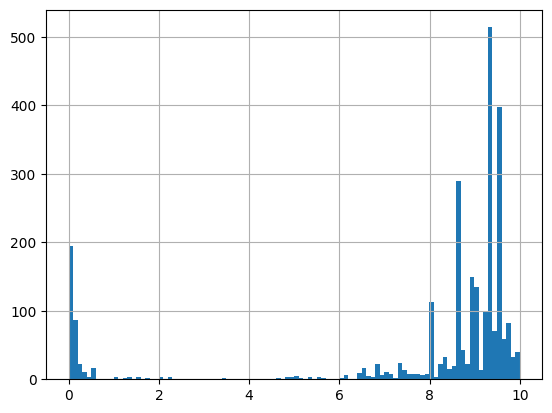

In [43]:
afs_sample_enhanced_w_salaries[afs_sample_enhanced_w_salaries['hourly_wage']<10]['hourly_wage'].hist(bins=100)

<Axes: >

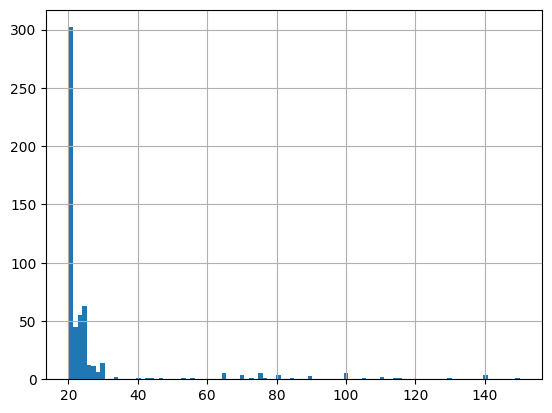

In [44]:
afs_sample_enhanced_w_salaries[afs_sample_enhanced_w_salaries['hourly_wage']>20]['hourly_wage'].hist(bins=100)

In [45]:
# Remove outlying salaries from the data.
# The minimum wage for 16 year olds in 2023 was £5.28 so realistically there shouldn't be hourly pay much lower than this.
afs_sample_enhanced_w_salaries = afs_sample_enhanced_w_salaries[(afs_sample_enhanced_w_salaries['hourly_wage']>=5)&(afs_sample_enhanced_w_salaries['hourly_wage']<50)]

In [46]:
# Export data for the boxplot of hourly wage by sector
afs_sample_enhanced_w_salaries[['id', 'sector', 'hourly_wage']].to_csv('salary_boxplot.csv')

In [47]:
# Data for the line plot of median salary by sector over time
afs_sample_enhanced_w_salaries.groupby(['year', 'sector']).agg({'hourly_wage': 'median'}).unstack(fill_value=0).to_csv('hourly_wage_by_year_and_sector.csv')

# Functions to extract hours

In [48]:
def match_hours_per_week(text):
    
    working_hours = []
    
    hours_pattern = re.compile(r"(\d{1,2}(?:-\d{1,2})?)\s*(hours|hrs|h|hour)\s*(per\s*week|p\/w|a\s*week)?", re.IGNORECASE)
    
    explicit_hours = hours_pattern.findall(text)
    
    if explicit_hours:
        for match in explicit_hours:
            hours_range = match[0]
            if '-' in hours_range:
                min_hours, max_hours = map(int, hours_range.split('-'))
            else:
                min_hours = max_hours = int(hours_range)
            working_hours.append({'min_hours': min_hours, 'max_hours': max_hours})
            
    return working_hours

In [49]:
hours_texts = ['40 hours per week',
'Full time Hours - 8:30am - 4:30pm',
'Working days : Tuesday 10am-2pm',
'35 hours per week',
'Full-time contract of employment, 39 hours per week',
'40-45 hours p/w',
'Full-time',
'4 Days a Week',
'4 days per week Monday – Thursday, 8.30AM – 3.30PM',
'part-time 24 hour per week contract',
'Working hours: 40 hours over 5 out of 7 days']

[match_hours_per_week(text) for text in hours_texts]

[[{'min_hours': 40, 'max_hours': 40}],
 [],
 [],
 [{'min_hours': 35, 'max_hours': 35}],
 [{'min_hours': 39, 'max_hours': 39}],
 [{'min_hours': 40, 'max_hours': 45}],
 [],
 [],
 [],
 [{'min_hours': 24, 'max_hours': 24}],
 [{'min_hours': 40, 'max_hours': 40}]]

In [50]:
from datetime import datetime, timedelta


def parse_time(time_str):
    # Define time formats to match various input patterns
    time_formats = [
        "%I:%M%p",  # e.g., "8:30am"
        "%I.%M%p",  # e.g., "8.30am"
        "%I:%M %p",  # e.g., "8:30 am"
        "%I.%M %p",  # e.g., "8.30 am"
        "%I%p",      # e.g., "8am"
        "%I %p",     # e.g., "8 am"
        "%I:%M",     # e.g., "8:30"
        "%I.%M",     # e.g., "8.30"
        "%I"         # e.g., "8"
    ]
    
    for time_format in time_formats:
        try:
            return datetime.strptime(time_str, time_format)
        except ValueError:
            continue
    return None

def extract_time_difference(text):
    # Regex pattern to capture time ranges
    time_range_pattern = re.compile(
        r"(\d{1,2}[:\.]\d{2}|\d{1,2})(?:\s*[apAP][mM])?\s*-\s*(\d{1,2}[:\.]\d{2}|\d{1,2})(?:\s*[apAP][mM])?",
        re.IGNORECASE
    )

    matches = time_range_pattern.findall(text)
    if not matches:
        return None

    for start_time_str, end_time_str in matches:
        # Clean up and parse the times
        start_time = parse_time(start_time_str.strip())
        end_time = parse_time(end_time_str.strip())

        if not start_time or not end_time:
            continue

        # If end time is earlier than start time, assume it spans to the next day (24-hour format)
        if end_time <= start_time:
            end_time += timedelta(hours=12)

        # Calculate the time difference in hours
        time_difference = (end_time - start_time).seconds / 3600.0
        return time_difference

    return None

In [51]:
texts = [
    "8.30-11.30am",
    "8.30am - 12.30pm",
    "8.30 am - 12.30 pm",
    "8:30 am - 12:30 pm",
    "12-6",
    "8 am - 12 pm"
]

for text in texts:
    time_diff = extract_time_difference(text)
    print(f"'{text}' => {time_diff} hours")

'8.30-11.30am' => 3.0 hours
'8.30am - 12.30pm' => 4.0 hours
'8.30 am - 12.30 pm' => 4.0 hours
'8:30 am - 12:30 pm' => 4.0 hours
'12-6' => 6.0 hours
'8 am - 12 pm' => 4.0 hours


In [52]:
def count_working_days(text):
    # Define day mappings to handle various abbreviations
    day_mappings = {
        'monday': 0, 'mon': 0, 'mondays': 0,
        'tuesday': 1, 'tue': 1, 'tues': 1, 'tuesdays': 1,
        'wednesday': 2, 'wed': 2, 'wednesdays': 2,
        'thursday': 3, 'thu': 3, 'thurs': 3, 'thursdays': 3,
        'friday': 4, 'fri': 4, 'fridays': 4,
        'saturday': 5, 'sat': 5, 'saturdays': 5,
        'sunday': 6, 'sun': 6, 'sundays': 6
    }
    
    # Handle ranges like "Mon - Thurs"
    range_pattern = re.compile(r"(\b\w+\b)\s*(-|to)\s*(\b\w+\b)", re.IGNORECASE)
    # Handle individual days or day lists like "Mondays, Tuesdays and Fridays"
    individual_days_pattern = re.compile(r"\b\w+\b", re.IGNORECASE)

    days = set()

    # Check for ranges
    if len(range_pattern.findall(text))>0:
        # print(range_pattern.findall(text))
        for match in range_pattern.findall(text):
            start_day = day_mappings.get(match[0].lower())
            end_day = day_mappings.get(match[2].lower())

            if start_day is not None and end_day is not None:
                # Add all days in the range to the set
                if start_day <= end_day:
                    for day in range(start_day, end_day + 1):
                        days.add(day)
                else:
                    # Handles cases where the range might go from end of the week to the start (e.g., Fri - Mon)
                    for day in range(start_day, 7):
                        days.add(day)
                    for day in range(0, end_day + 1):
                        days.add(day)
    else:
        # Check for individual days
        for day in individual_days_pattern.findall(text):
            day_index = day_mappings.get(day.lower())
            if day_index is not None:
                days.add(day_index)
    
    # print(days)
    return len(days)

# Example usage
texts = [
    "Monday - Thursday",
    "Mon - Thurs",
    "Mondays, Tuesdays and Fridays",
    "Fri - Mon",
    "Tuesday to Friday",
    "Saturday - Sunday",
    "Wed, Thu, Fri"
]

for text in texts:
    day_count = count_working_days(text)
    print(f"'{text}' => {day_count} days")


'Monday - Thursday' => 4 days
'Mon - Thurs' => 4 days
'Mondays, Tuesdays and Fridays' => 3 days
'Fri - Mon' => 4 days
'Tuesday to Friday' => 4 days
'Saturday - Sunday' => 2 days
'Wed, Thu, Fri' => 3 days
